# Analysis, Anomalies & Predictive Analytics

## Manufacturing Robot Data Analysis

This notebook analyzes the robot data retrieved from the team's Neon PostgreSQL database.

### Objectives

- Investigate patterns and trends in the robot data.
- Identify potential anomalies.
- Analyze whether detected anomalies affect robot operation.
- Define possible Maintenance Notification alerts.
- Analyze the robot's operational state based on the data.
- Implement the Predictive Analytics component required by the workshop.
- Visualize relevant findings.
- Explain the business and predictive maintenance significance of the results.

## 1. Data Retrieval from Neon PostgreSQL

The analysis uses the robot data stored in the team's Neon PostgreSQL database.

The existing database service developed by the team is reused to retrieve the records without modifying the shared project components.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.database_service import get_records

print("Analysis environment ready.")

Analysis environment ready.


In [2]:
import os

print("DATABASE_URL loaded:", bool(os.getenv("DATABASE_URL")))

DATABASE_URL loaded: True


## 2. Retrieve Robot Data from the Team Database

The existing `get_records()` function from the team's database service is used to retrieve the robot data stored in Neon PostgreSQL.

This analysis performs read-only access to the existing data. No records are inserted, updated, or deleted.

In [3]:
records = get_records()

print(f"Total records retrieved: {len(records)}")

Database connected successfully.
5 record(s) retrieved from Neon.
Total records retrieved: 5


## 4. Load the Complete Robot Dataset into Neon

The team database currently contains only a small number of test records.

To perform the required analysis using the complete historical dataset, the CSV data will be loaded into the existing `robot_data` table.

The existing database structure is preserved. Records are inserted in batches, and the existing unique timestamp constraint prevents duplicate records from being added.

In [4]:
csv_path = "data/robot_data.csv"

csv_df = pd.read_csv(csv_path)

print("CSV shape:", csv_df.shape)
print("\nCSV columns:")
print(csv_df.columns.tolist())

display(csv_df.head())

CSV shape: (39672, 16)

CSV columns:
['Trait', 'Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8', 'Axis #9', 'Axis #10', 'Axis #11', 'Axis #12', 'Axis #13', 'Axis #14', 'Time']


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z


### Validate CSV Schema Before Database Upload

The complete CSV contains 39,672 records. Before uploading the dataset to Neon, the CSV schema is inspected to determine how its columns map to the existing `robot_data` table.

In [5]:
for i, column in enumerate(csv_df.columns, start=1):
    print(f"{i}: {column}")

1: Trait
2: Axis #1
3: Axis #2
4: Axis #3
5: Axis #4
6: Axis #5
7: Axis #6
8: Axis #7
9: Axis #8
10: Axis #9
11: Axis #10
12: Axis #11
13: Axis #12
14: Axis #13
15: Axis #14
16: Time


### Complete Database Schema

The source dataset contains fourteen robot axes (`Axis #1` through `Axis #14`), while the initial database implementation contains only eight axis columns.

To preserve the complete dataset for analysis, the existing `robot_data` table is extended with columns `axis_9` through `axis_14` before the historical dataset is uploaded.

In [6]:
from src.database_service import connect_db

connection = connect_db()
cursor = connection.cursor()

for axis_number in range(9, 15):
    cursor.execute(
        f"ALTER TABLE robot_data "
        f"ADD COLUMN IF NOT EXISTS axis_{axis_number} DOUBLE PRECISION"
    )

connection.commit()
cursor.close()
connection.close()

print("Database schema now supports Axis #1 through Axis #14.")

Database connected successfully.
Database schema now supports Axis #1 through Axis #14.


### Validate Record Uniqueness Before Upload

Before uploading the complete dataset, the timestamp structure is validated against the existing database uniqueness constraint.

This prevents valid robot measurements from being accidentally discarded as duplicate records.

In [7]:
print("Total CSV records:", len(csv_df))
print("Unique Time values:", csv_df["Time"].nunique())
print("Unique Trait + Time combinations:",
      csv_df[["Trait", "Time"]].drop_duplicates().shape[0])

print("\nRecords by Trait:")
print(csv_df["Trait"].value_counts())

duplicate_times = csv_df.duplicated(subset=["Time"]).sum()
duplicate_trait_times = csv_df.duplicated(
    subset=["Trait", "Time"]
).sum()

print("\nDuplicate Time values:", duplicate_times)
print("Duplicate Trait + Time combinations:", duplicate_trait_times)

Total CSV records: 39672
Unique Time values: 39672
Unique Trait + Time combinations: 39672

Records by Trait:
Trait
current    39672
Name: count, dtype: int64

Duplicate Time values: 0
Duplicate Trait + Time combinations: 0


### Upload Complete Historical Dataset to Neon

The complete historical robot dataset is uploaded to the existing Neon PostgreSQL database using a batch operation.

All fourteen robot axes are preserved. The existing timestamp uniqueness constraint prevents duplicate records from being inserted.

In [8]:
timestamps = pd.to_datetime(csv_df["Time"], utc=True)

upload_df = csv_df.copy()

upload_df["year"] = timestamps.dt.year
upload_df["month"] = timestamps.dt.month
upload_df["day"] = timestamps.dt.day
upload_df["db_time"] = timestamps.dt.time

insert_columns = (
    ["Trait"]
    + [f"Axis #{i}" for i in range(1, 15)]
    + ["year", "month", "day", "db_time"]
)

rows = list(
    upload_df[insert_columns].itertuples(index=False, name=None)
)

connection = connect_db()
cursor = connection.cursor()

cursor.executemany(
    """
    INSERT INTO robot_data (
        trait,
        axis_1, axis_2, axis_3, axis_4,
        axis_5, axis_6, axis_7, axis_8,
        axis_9, axis_10, axis_11, axis_12,
        axis_13, axis_14,
        year, month, day, time
    )
    VALUES (
        %s, %s, %s, %s, %s,
        %s, %s, %s, %s, %s,
        %s, %s, %s, %s, %s,
        %s, %s, %s, %s
    )
    ON CONFLICT (year, month, day, time) DO NOTHING
    """,
    rows
)

connection.commit()

cursor.execute("SELECT COUNT(*) FROM robot_data")
total_records = cursor.fetchone()[0]

cursor.close()
connection.close()

print("Bulk upload completed.")
print(f"CSV records: {len(csv_df):,}")
print(f"Records currently in Neon: {total_records:,}")

Database connected successfully.
Bulk upload completed.
CSV records: 39,672
Records currently in Neon: 39,672


## 5. Retrieve the Complete Dataset from Neon

The complete historical dataset is now stored in Neon PostgreSQL.

For the analysis, the data is retrieved directly from the database rather than from the original CSV. This ensures that the analysis and visualizations use the centralized data source implemented by the team.

In [9]:
connection = connect_db()
cursor = connection.cursor()

cursor.execute("SELECT * FROM robot_data ORDER BY id")

records = cursor.fetchall()
column_names = [description.name for description in cursor.description]

cursor.close()
connection.close()

df = pd.DataFrame(records, columns=column_names)

print("Records retrieved from Neon:", len(df))
print("DataFrame shape:", df.shape)

display(df.head())

Database connected successfully.
Records retrieved from Neon: 39672
DataFrame shape: (39672, 20)


,id,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,year,month,day,time,axis_9,axis_10,axis_11,axis_12,axis_13,axis_14
0,2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022,10,17,12:18:23.660000,NaN,NaN,NaN,NaN,NaN,NaN
1,3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022,10,17,12:18:25.472000,NaN,NaN,NaN,NaN,NaN,NaN
2,4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022,10,17,12:18:27.348000,NaN,NaN,NaN,NaN,NaN,NaN
3,5,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022,10,17,12:18:29.222000,NaN,NaN,NaN,NaN,NaN,NaN
4,6,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022,10,17,12:18:31.117000,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Pattern and Statistical Analysis

Descriptive statistics are calculated for all fourteen robot axes to identify their typical operating ranges, variability, minimum and maximum values, and potential unusual behavior.

These statistics provide a baseline for identifying abnormal robot measurements and possible maintenance conditions.

In [10]:
axis_columns = [f"axis_{i}" for i in range(1, 15)]

statistics = df[axis_columns].describe().T

statistics["range"] = statistics["max"] - statistics["min"]

display(statistics)

,count,mean,std,min,25%,50%,75%,max,range
axis_1,39672.0,0.725743,2.162120,0.0,0.0,0.0,0.31271,23.60930,23.60930
axis_2,39672.0,3.613374,6.879962,0.0,0.0,0.0,4.21719,51.71323,51.71323
axis_3,39672.0,2.710336,5.111901,0.0,0.0,0.0,4.58619,41.85556,41.85556
axis_4,39672.0,0.620222,1.574897,0.0,0.0,0.0,0.51619,15.66630,15.66630
axis_5,39672.0,0.954521,2.100186,0.0,0.0,0.0,0.80009,20.75076,20.75076
axis_6,39672.0,0.599427,1.815498,0.0,0.0,0.0,0.36133,20.93142,20.93142
axis_7,39672.0,0.870145,2.166811,0.0,0.0,0.0,0.31003,8.10848,8.10848
axis_8,39672.0,0.102214,0.423075,0.0,0.0,0.0,0.07848,5.90564,5.90564
axis_9,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
axis_10,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Anomaly Detection

Potential anomalies are identified using the three-standard-deviation rule.

For each robot axis, a measurement is considered a potential anomaly when it falls more than three standard deviations above or below the mean value of that axis.

This method provides a simple statistical approach for identifying unusual robot behavior that may require further investigation or maintenance attention.

In [11]:
anomaly_summary = []

for axis in axis_columns:
    mean = df[axis].mean()
    std = df[axis].std()

    lower_limit = mean - (3 * std)
    upper_limit = mean + (3 * std)

    anomaly_mask = (
        (df[axis] < lower_limit) |
        (df[axis] > upper_limit)
    )

    anomaly_count = anomaly_mask.sum()

    anomaly_summary.append({
        "Axis": axis,
        "Mean": mean,
        "Std Dev": std,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Anomalies": anomaly_count,
        "Anomaly %": (anomaly_count / len(df)) * 100
    })

anomaly_summary_df = pd.DataFrame(anomaly_summary)

display(anomaly_summary_df)

,Axis,Mean,Std Dev,Lower Limit,Upper Limit,Anomalies,Anomaly %
0,axis_1,0.725743,2.162120,-5.760617,7.212102,1005,2.533273
1,axis_2,3.613374,6.879962,-17.026511,24.253259,892,2.248437
2,axis_3,2.710336,5.111901,-12.625366,18.046039,1023,2.578645
3,axis_4,0.620222,1.574897,-4.104468,5.344912,901,2.271123
4,axis_5,0.954521,2.100186,-5.346037,7.255079,872,2.198024
5,axis_6,0.599427,1.815498,-4.847067,6.045921,1041,2.624017
6,axis_7,0.870145,2.166811,-5.630287,7.370578,2971,7.488909
7,axis_8,0.102214,0.423075,-1.167011,1.371440,657,1.656080
8,axis_9,NaN,NaN,NaN,NaN,0,0.000000
9,axis_10,NaN,NaN,NaN,NaN,0,0.000000


## 8. Robot State and Maintenance Notifications

The anomaly analysis is performed using the robot axes that contain actual measurements.

Each database record is evaluated using the three-standard-deviation anomaly limits calculated from the historical data.

The number of simultaneous abnormal axis measurements is used to classify the robot condition:

- **NORMAL:** No abnormal axis measurements.
- **WARNING:** One abnormal axis measurement.
- **MAINTENANCE:** Two or more abnormal axis measurements.

This classification provides a simple maintenance notification mechanism that can be applied to streamed robot data.

In [12]:
# Use only axes containing actual measurements
active_axes = [
    axis for axis in axis_columns
    if df[axis].notna().any()
]

print("Active axes:", active_axes)

# Calculate historical limits
means = df[active_axes].mean()
stds = df[active_axes].std()

lower_limits = means - (3 * stds)
upper_limits = means + (3 * stds)

# Detect anomalies for every record and every active axis
anomaly_flags = (
    df[active_axes].lt(lower_limits) |
    df[active_axes].gt(upper_limits)
)

# Number of abnormal axes in each record
df["anomaly_count"] = anomaly_flags.sum(axis=1)

# Robot operational state
df["robot_state"] = np.select(
    [
        df["anomaly_count"] >= 2,
        df["anomaly_count"] == 1
    ],
    [
        "MAINTENANCE",
        "WARNING"
    ],
    default="NORMAL"
)

# Maintenance notification
df["maintenance_notification"] = np.where(
    df["robot_state"] == "MAINTENANCE",
    "Maintenance inspection recommended",
    np.where(
        df["robot_state"] == "WARNING",
        "Monitor abnormal axis",
        "No maintenance alert"
    )
)

print("\nRobot State Summary:")
print(df["robot_state"].value_counts())

print("\nRobot State Percentage:")
print(
    (df["robot_state"].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nTotal records analyzed:", len(df))
print("Records with at least one anomaly:",
      (df["anomaly_count"] > 0).sum())

print("Records requiring maintenance inspection:",
      (df["robot_state"] == "MAINTENANCE").sum())

Active axes: ['axis_1', 'axis_2', 'axis_3', 'axis_4', 'axis_5', 'axis_6', 'axis_7', 'axis_8']

Robot State Summary:
robot_state
NORMAL         32307
WARNING         5597
MAINTENANCE     1768
Name: count, dtype: int64

Robot State Percentage:
robot_state
NORMAL         81.44
WARNING        14.11
MAINTENANCE     4.46
Name: proportion, dtype: float64

Total records analyzed: 39672
Records with at least one anomaly: 7365
Records requiring maintenance inspection: 1768


### Axis Maintenance Priority

The number of anomalies detected in each active robot axis is compared to identify which component should receive maintenance attention first.

In [13]:
axis_anomaly_counts = (
    anomaly_flags.sum()
    .sort_values(ascending=False)
)

axis_anomaly_percentages = (
    axis_anomaly_counts / len(df) * 100
).round(2)

maintenance_priority = pd.DataFrame({
    "Anomalies": axis_anomaly_counts,
    "Anomaly %": axis_anomaly_percentages
})

display(maintenance_priority)

highest_priority_axis = maintenance_priority.index[0]

print(
    f"\nHighest maintenance priority: "
    f"{highest_priority_axis}"
)

,Anomalies,Anomaly %
axis_7,2971,7.49
axis_6,1041,2.62
axis_3,1023,2.58
axis_1,1005,2.53
axis_4,901,2.27
axis_2,892,2.25
axis_5,872,2.20
axis_8,657,1.66



Highest maintenance priority: axis_7


## 9. Anomaly Visualization by Robot Axis

The anomaly rate of each active robot axis is compared to identify which component shows the highest frequency of abnormal behavior.

A higher anomaly percentage indicates that the axis operates outside its historical three-standard-deviation range more frequently and may require additional monitoring or maintenance attention.

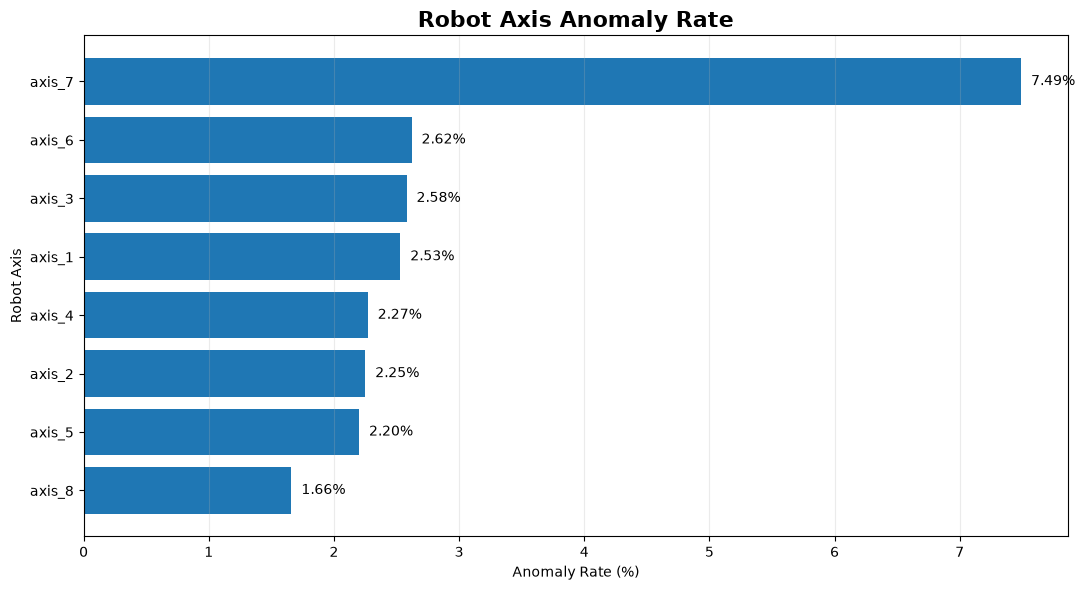

In [14]:
plt.figure(figsize=(11, 6))

plot_data = maintenance_priority.sort_values("Anomaly %")

bars = plt.barh(
    plot_data.index,
    plot_data["Anomaly %"]
)

plt.title(
    "Robot Axis Anomaly Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Anomaly Rate (%)")
plt.ylabel("Robot Axis")

plt.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, plot_data["Anomaly %"]):
    plt.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 10. Highest-Priority Axis Anomaly Detection

Axis 7 contains the highest number of detected anomalies.

The following visualization compares the historical Axis 7 measurements against its three-standard-deviation operating limits. Measurements outside these limits are highlighted as potential abnormal robot behavior.

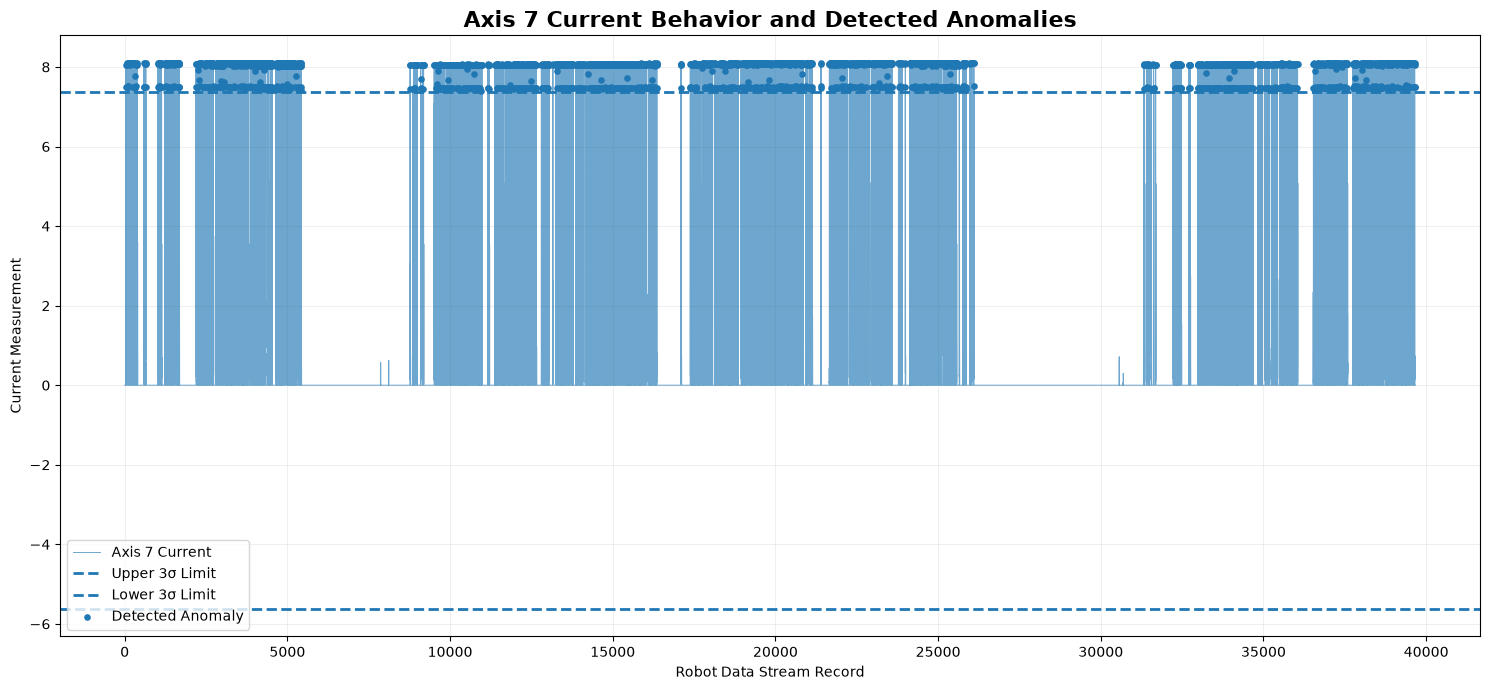

In [15]:
axis = "axis_7"

mean = df[axis].mean()
std = df[axis].std()

lower_limit = mean - (3 * std)
upper_limit = mean + (3 * std)

axis_anomalies = (
    (df[axis] < lower_limit) |
    (df[axis] > upper_limit)
)

plt.figure(figsize=(15, 7))

plt.plot(
    df.index,
    df[axis],
    linewidth=0.7,
    alpha=0.65,
    label="Axis 7 Current"
)

plt.axhline(
    upper_limit,
    linestyle="--",
    linewidth=2,
    label="Upper 3σ Limit"
)

plt.axhline(
    lower_limit,
    linestyle="--",
    linewidth=2,
    label="Lower 3σ Limit"
)

plt.scatter(
    df.index[axis_anomalies],
    df.loc[axis_anomalies, axis],
    s=14,
    label="Detected Anomaly",
    zorder=3
)

plt.title(
    "Axis 7 Current Behavior and Detected Anomalies",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Robot Data Stream Record")
plt.ylabel("Current Measurement")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 11. Full Dataset Robot Current Profile

The complete historical dataset is summarized to visualize the combined current behavior of the robot axes.

All database records are included in the analysis. Measurements are grouped into sequential windows to make long-term patterns visible while preserving the overall behavior of the complete dataset.

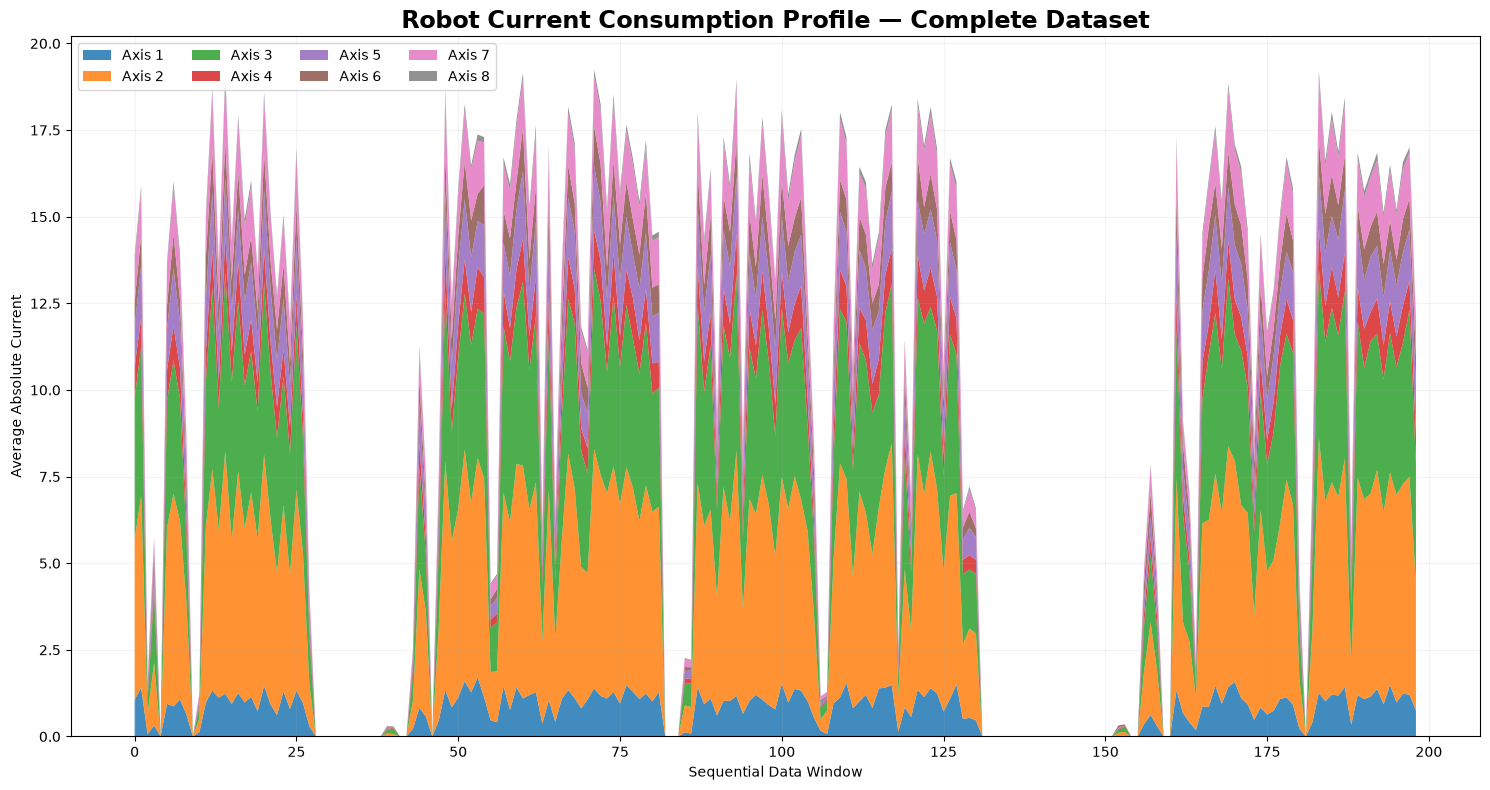

In [16]:
active_data = df[active_axes].abs().copy()

window_size = 200

group_number = np.arange(len(active_data)) // window_size

profile = active_data.groupby(group_number).mean()

plt.figure(figsize=(15, 8))

plt.stackplot(
    profile.index,
    *[profile[axis] for axis in active_axes],
    labels=[
        axis.replace("axis_", "Axis ")
        for axis in active_axes
    ],
    alpha=0.85
)

plt.title(
    "Robot Current Consumption Profile — Complete Dataset",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Sequential Data Window")
plt.ylabel("Average Absolute Current")

plt.legend(
    loc="upper left",
    ncol=4
)

plt.grid(alpha=0.15)

plt.tight_layout()
plt.show()

## 12. Robot Motor Current Consumption Trend

This stacked area chart follows the visualization style presented in the workshop.

It displays a recent window of measurements from six robot axes and applies a rolling average to make the operating cycles and motor current-consumption trends easier to identify.

The visualization uses robot measurements retrieved from the team's Neon PostgreSQL database and supports condition monitoring by making changes in current consumption visually identifiable.

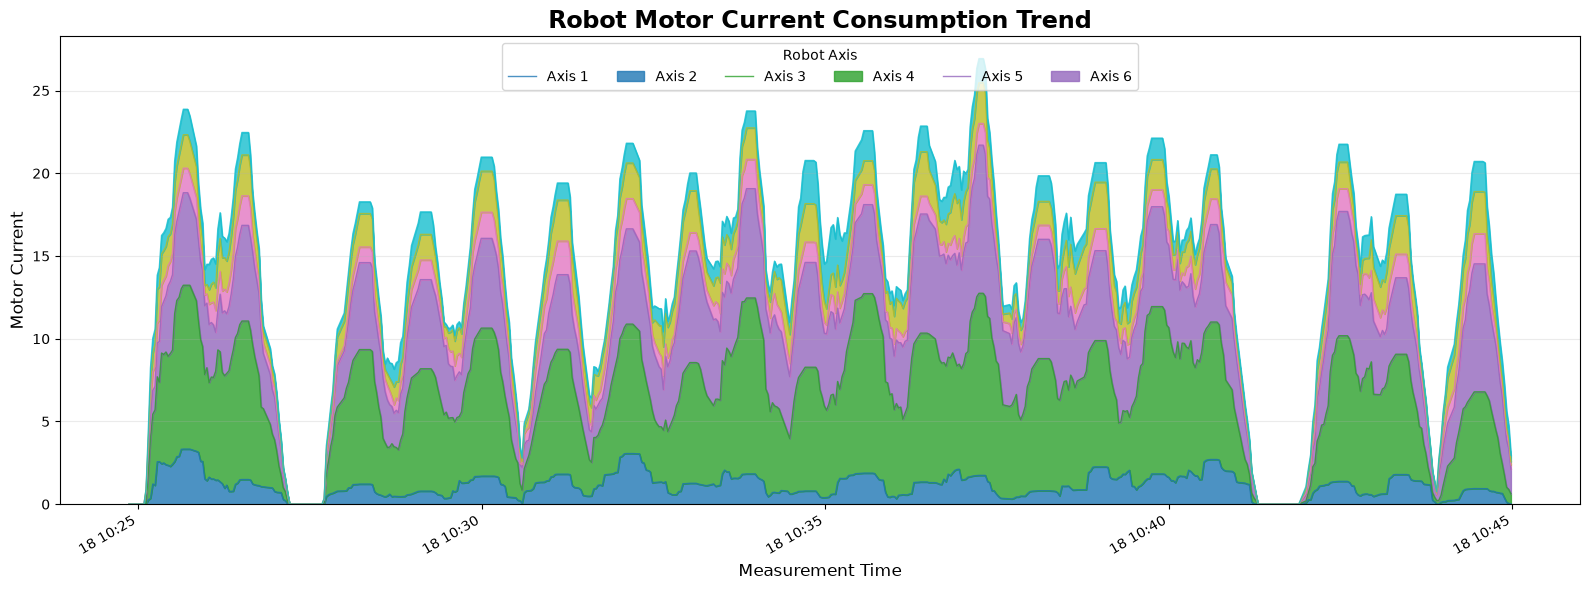

In [19]:
# Robot Motor Current Consumption Trend
# Visualization based on the workshop example

# Use the six robot axes represented in the workshop visualization
professor_chart_axes = [
    "axis_1",
    "axis_2",
    "axis_3",
    "axis_4",
    "axis_5",
    "axis_6"
]

# Sort the Neon data chronologically
chart_data = (
    df.sort_values("timestamp")
      .tail(600)
      .set_index("timestamp")[professor_chart_axes]
      .clip(lower=0)
)

# Smooth short fluctuations to reveal operating cycles
smoothed_chart_data = (
    chart_data
    .rolling(
        window=20,
        min_periods=1
    )
    .mean()
)

# Create the stacked area chart
ax = smoothed_chart_data.plot.area(
    stacked=True,
    figsize=(16, 6),
    alpha=0.8,
    linewidth=1,
    colormap="tab10"
)

plt.title(
    "Robot Motor Current Consumption Trend",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Measurement Time",
    fontsize=12
)

plt.ylabel(
    "Motor Current",
    fontsize=12
)

plt.legend(
    title="Robot Axis",
    labels=[
        "Axis 1",
        "Axis 2",
        "Axis 3",
        "Axis 4",
        "Axis 5",
        "Axis 6"
    ],
    loc="upper center",
    ncol=6
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

## 13. Predictive Analytics for Maintenance

The Predictive Analytics component uses historical anomaly behavior to provide an early indication of possible maintenance needs.

Instead of attempting to predict a specific mechanical failure without labeled failure data, the historical robot measurements are divided into sequential operating windows. The anomaly rate in each window is calculated and used to identify whether abnormal behavior is increasing over time.

This provides a simple predictive-maintenance foundation that can later be extended with labeled maintenance or failure records.

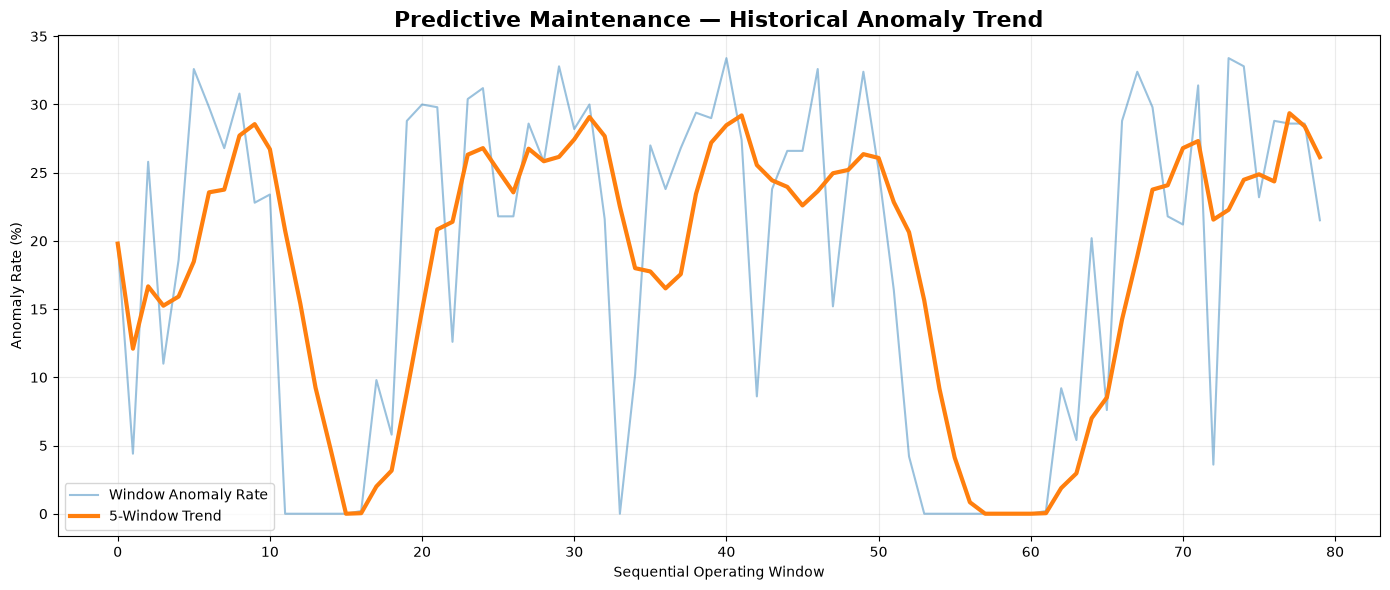

Latest anomaly trend: 26.14%


In [20]:
# Predictive Analytics foundation using historical anomaly behavior

predictive_df = df.copy()

# Each record is abnormal if at least one active axis is outside
# its historical three-standard-deviation limits
predictive_df["is_anomaly"] = (
    anomaly_flags.any(axis=1)
).astype(int)

# Divide historical data into sequential operating windows
window_size = 500

predictive_df["analysis_window"] = (
    np.arange(len(predictive_df)) // window_size
)

# Calculate anomaly rate for each historical window
predictive_trend = (
    predictive_df
    .groupby("analysis_window")["is_anomaly"]
    .mean()
    .mul(100)
)

# Rolling trend for easier interpretation
predictive_average = (
    predictive_trend
    .rolling(window=5, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    predictive_trend.index,
    predictive_trend.values,
    alpha=0.45,
    label="Window Anomaly Rate"
)

plt.plot(
    predictive_average.index,
    predictive_average.values,
    linewidth=3,
    label="5-Window Trend"
)

plt.title(
    "Predictive Maintenance — Historical Anomaly Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sequential Operating Window")
plt.ylabel("Anomaly Rate (%)")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(
    f"Latest anomaly trend: "
    f"{predictive_average.iloc[-1]:.2f}%"
)

## 14. Findings and Business Significance

### Pattern Analysis

The historical robot data shows repeated operating cycles and changes in motor current consumption across the active robot axes. The stacked area visualization makes these operating patterns visible and provides a baseline for identifying unusual behavior.

### Anomaly Detection

Potential anomalies were identified using the three-standard-deviation rule. Axis 7 showed the highest anomaly frequency, with 2,971 abnormal measurements (7.49% of the historical records). This makes Axis 7 the highest-priority axis for additional monitoring.

An anomaly does not necessarily indicate a mechanical failure. It indicates that the measurement is outside the expected historical operating range and should be investigated in the context of the robot's operating condition.

### Robot State Analysis

The anomaly results can be used to classify the robot's operating condition. Measurements within the historical limits represent normal operation, while measurements outside those limits indicate conditions that should be monitored.

Multiple simultaneous abnormal axis measurements provide a stronger indication that maintenance inspection may be appropriate.

### Maintenance Notification

A simple maintenance notification strategy can use the detected anomalies:

- **NORMAL:** No abnormal axis measurements detected.
- **WARNING:** One axis is operating outside its historical range.
- **MAINTENANCE:** Multiple axes are simultaneously operating outside their historical ranges.

Axis 7 should receive particular attention because it produced the highest historical anomaly rate.

### Predictive Analytics

The Predictive Analytics component evaluates how the anomaly rate changes across sequential historical operating windows.

The latest five-window anomaly trend is approximately **26.14%**. This value should not be interpreted as a probability of equipment failure. Instead, it represents the recent frequency of statistically abnormal measurements and can be used as an early condition-monitoring indicator.

A sustained increase in this trend could trigger additional monitoring or maintenance inspection.

A future predictive model could combine these measurements with labeled maintenance and equipment-failure records to estimate actual failure risk and remaining useful life.

### Business Significance

Condition monitoring can help maintenance teams identify unusual robot behavior before it develops into a more serious operational problem.

Using historical motor-current measurements, anomaly detection, maintenance notifications, and predictive trends can support earlier inspections, reduce unexpected downtime, and help maintenance resources focus on the robot components showing the strongest evidence of abnormal behavior.